In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Green data ----------
#data22 = pd.read_csv('UofU 650-05-218 BHA 22 - output data.csv', skiprows=35) no bit vibration data
data34 = pd.read_csv('BHA 34 650-05-551 - output data.csv', skiprows=35)
# Blue data -----------
data18 = pd.read_csv('UofU 650-05-376 BHA 18 - output data.csv', skiprows=35)
data30 = pd.read_csv('UofU 650-05-438 BHA 30 - output data.csv', skiprows=35)
# Orange data ---------
#data21 = pd.read_csv("UofU 650-05-218 BHA 21 - output data.csv", skiprows=35) no bit vibration data
data35r1 = pd.read_csv("BHA 35r1 650-05-551 - output data.csv", skiprows=35)
data35r2 = pd.read_csv("BHA 35r2 650-05-551 - output data.csv", skiprows=35)
data35 = pd.concat([data35r1, data35r2])
# Red data ------------
data23 = pd.read_csv("DATAMwEDR_UofU 650-05-211 BHA 23 - output data.csv", skiprows=35)
data38 = pd.read_csv("UofU 650-05-546 BHA 38 - output data.csv", skiprows=35)
data39 = pd.read_csv("UofU 650-05-546 BHA 39 - output data.csv", skiprows=35)
data42 = pd.read_csv("BHA 42 650-05-413 - output data.csv", skiprows=35)

torsionalCol = "Bit Box_ShYpeak(g)"
lateralCol = "Bit Box_ShZpeak(g)"
axialCol = "Bit Box_ShXpeak(g)"
necessaryVars = ["Surface_GC_OnBottom(bool)", "Surface_Top Drive RPM(RPM)", "Surface_GC_Rotating(bool)",\
                 "Surface_Flow In(GPM)", "Surface_Weight on Bit(klbs)", "Surface_GC_Sliding(bool)",\
                 torsionalCol, lateralCol, axialCol]
datasetList = [data34, data18, data30, data35, data23, data38, data39, data42]

In [4]:
dataG = data34.copy()
dataB = pd.concat([data18.copy(), data30.copy()])
dataO = data35.copy()
dataR = pd.concat([data23.copy(), data38.copy(), data39.copy(), data42.copy()])
groupedDatasets = {"dataG": dataG, 
                   "dataB": dataB,
                   "dataO": dataO,
                   "dataR": dataR
                   }

In [5]:
for name, df in groupedDatasets.items():
    df = df.copy()
    df["Augmented RPM(RPM)"] = np.where(
        df["Surface_GC_Rotating(bool)"] == 1,
        df["Surface_Flow In(GPM)"] * 0.242 + df["Surface_Top Drive RPM(RPM)"],
        df["Surface_Flow In(GPM)"] * 0.242
    )

    # filter rows
    df = df.loc[df["Augmented RPM(RPM)"].between(10, 250)].copy()

    # store back into dict
    groupedDatasets[name] = df

In [6]:
groupedDataDrilling = {}
groupedNotDrilling = {}

for name, df in groupedDatasets.items():
    df = df.loc[df["Surface_Weight on Bit(klbs)"] < 100].copy()
    df = df.dropna(subset=[torsionalCol]).copy()

    dataDrilling = df.loc[df["Surface_GC_OnBottom(bool)"] == 1].copy()
    dataDrilling = dataDrilling[dataDrilling["Surface_Weight on Bit(klbs)"] > 10].copy()
    groupedDataDrilling[name] = dataDrilling

    z = df.loc[df["Surface_GC_OnBottom(bool)"] == 0].copy()
    z.loc[:, "Surface_Weight on Bit(klbs)"] = 0
    groupedNotDrilling[name] = z


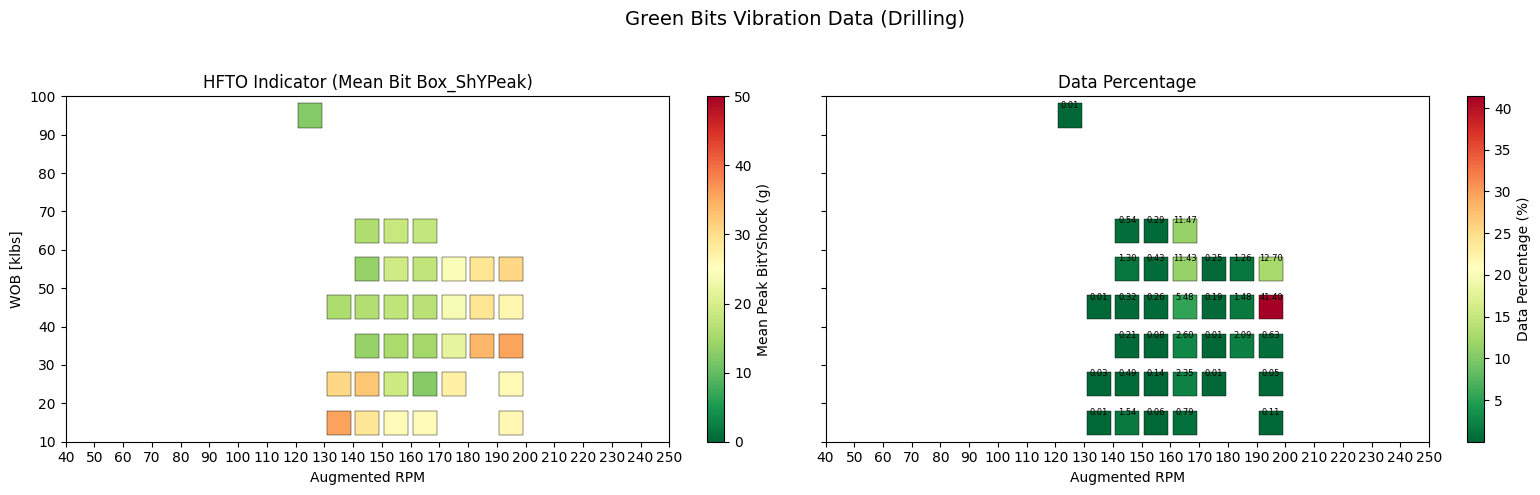

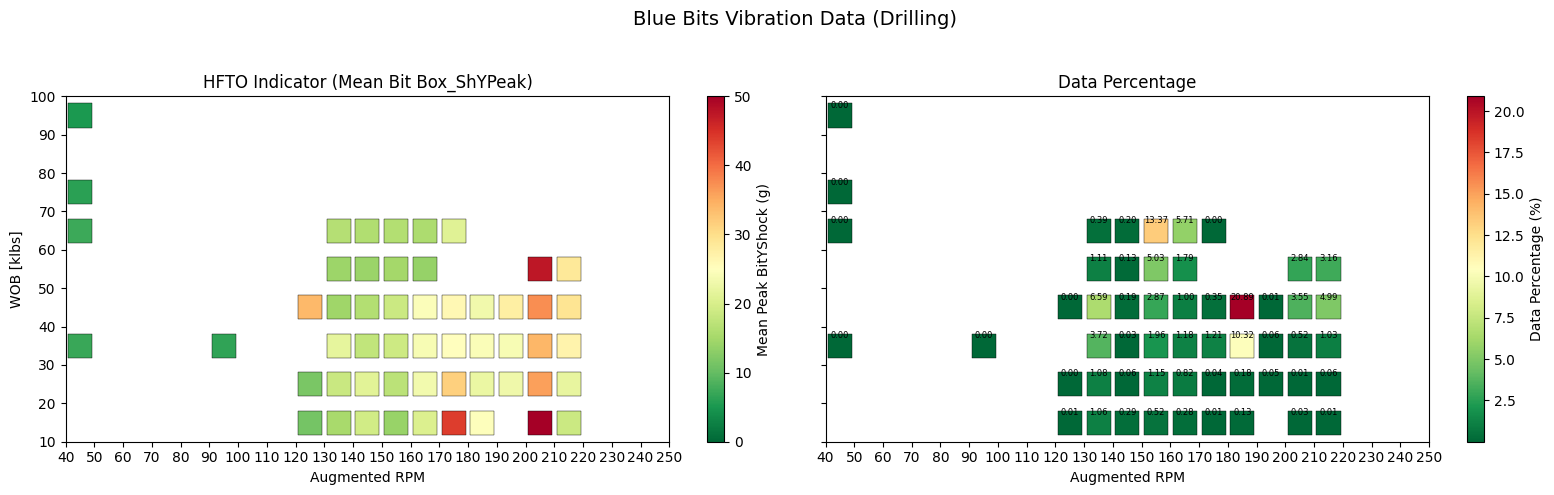

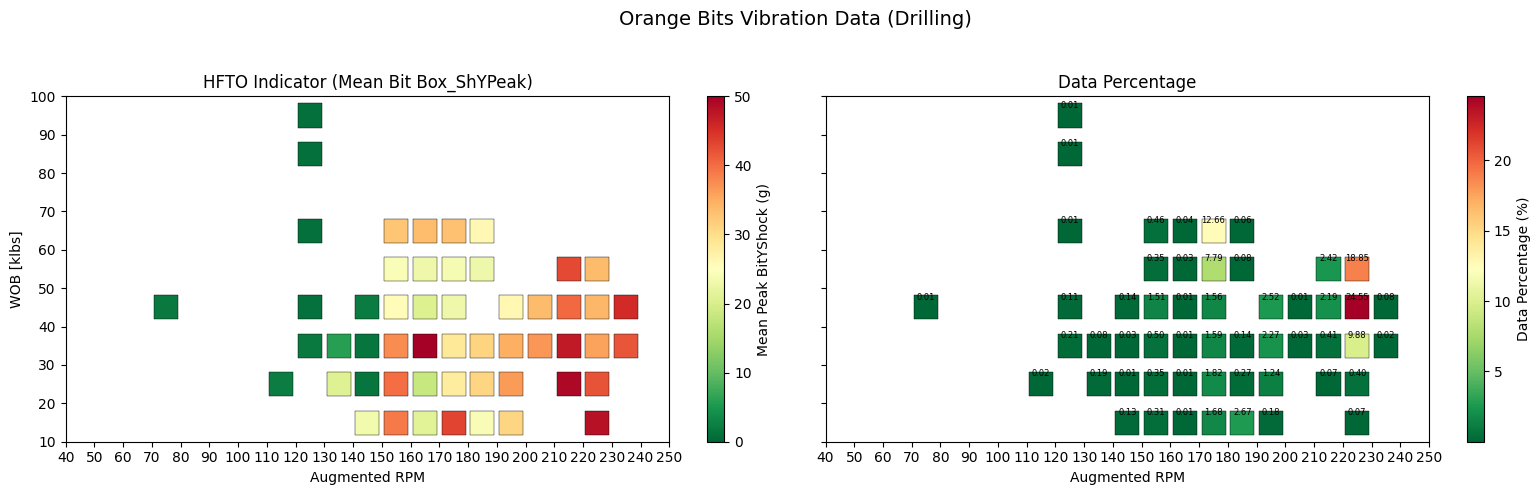

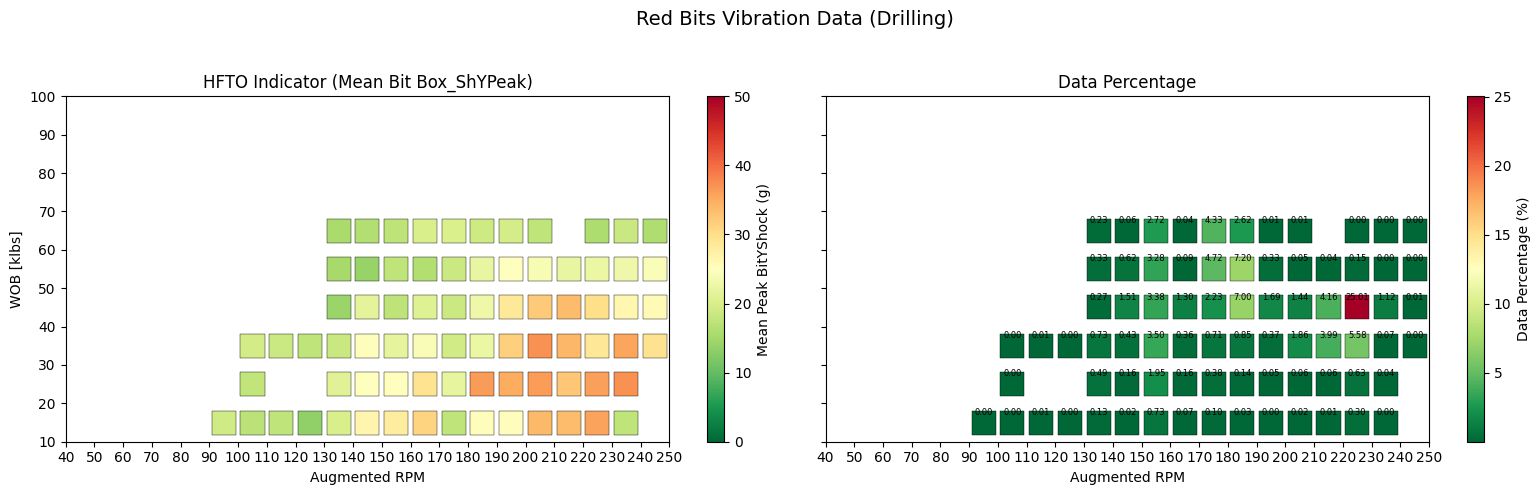

In [7]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "Green Bits Vibration Data (Drilling)": groupedDataDrilling["dataG"],
    "Blue Bits Vibration Data (Drilling)": groupedDataDrilling["dataB"],
    "Orange Bits Vibration Data (Drilling)": groupedDataDrilling["dataO"],
    "Red Bits Vibration Data (Drilling)": groupedDataDrilling["dataR"]
    #"Green Bit Vibration Data (Not Drilling)": groupedNotDrilling["dataG"]
}

selected_states = {
    "Green Bits Vibration Data (Drilling)": groupedDataDrilling["dataG"],
    "Blue Bits Vibration Data (Drilling)": groupedDataDrilling["dataB"],
    "Orange Bits Vibration Data (Drilling)": groupedDataDrilling["dataO"],
    "Red Bits Vibration Data (Drilling)": groupedDataDrilling["dataR"]
    #"Green Bit Vibration Data (Not Drilling)": groupedNotDrilling["dataG"]
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = torsionalCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in selected_states.values())
maxrpm_raw = max(df[rpm_col].max() for df in selected_states.values())

minwob_raw = min(df[wob_col].min() for df in selected_states.values())
maxwob_raw = max(df[wob_col].max() for df in selected_states.values())

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShYPeak)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean Peak BitYShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)


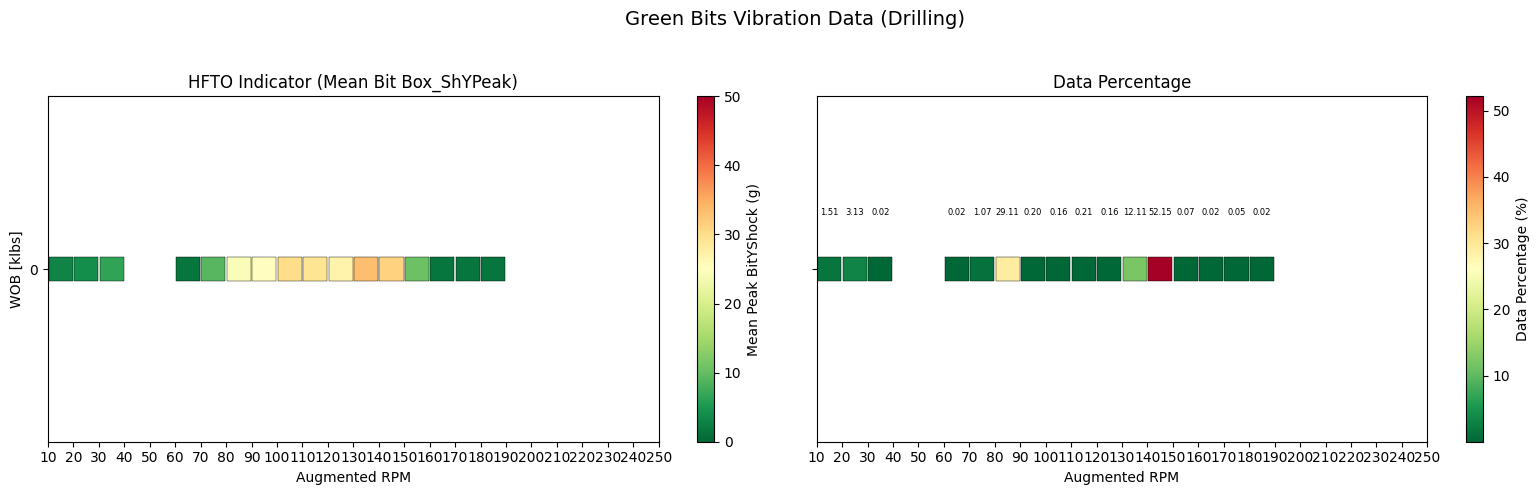

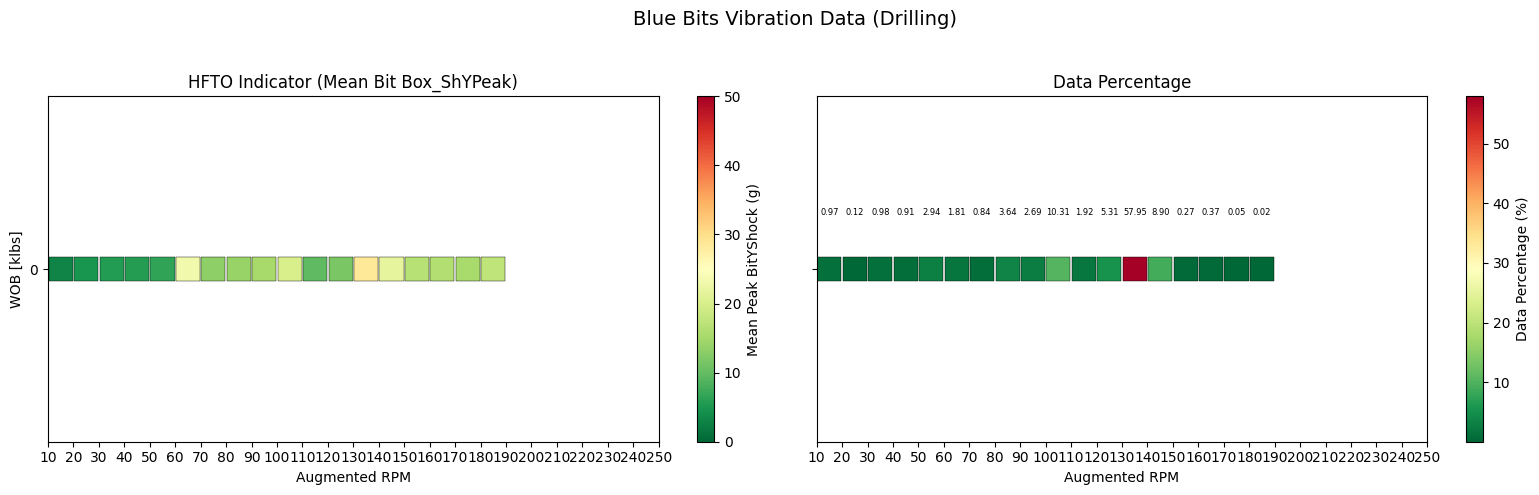

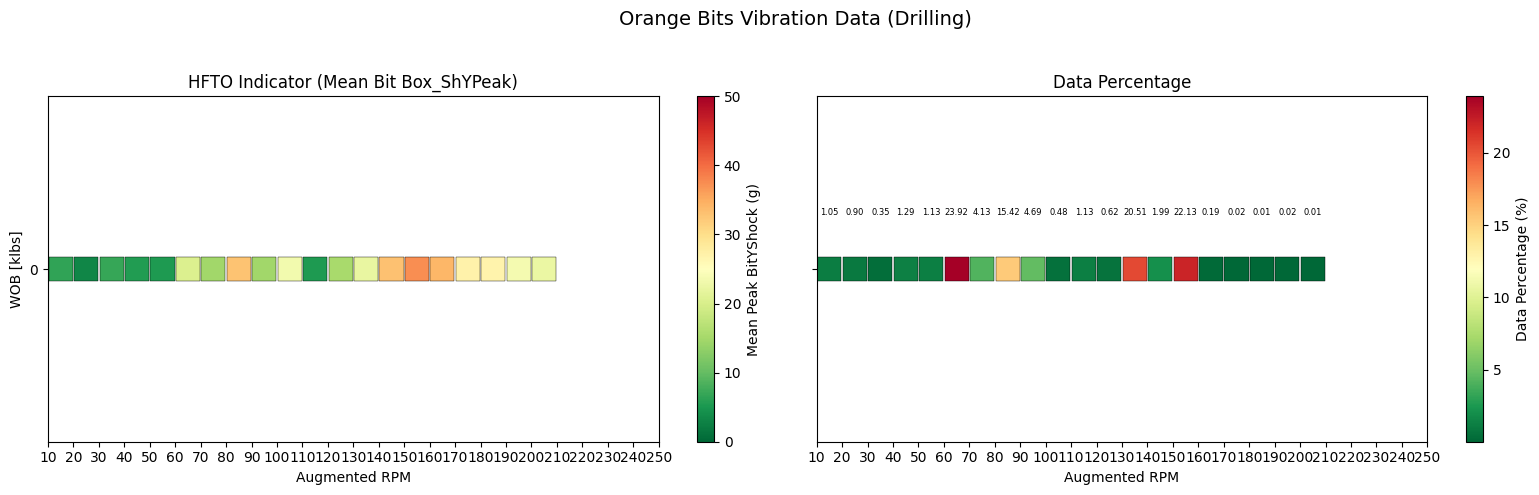

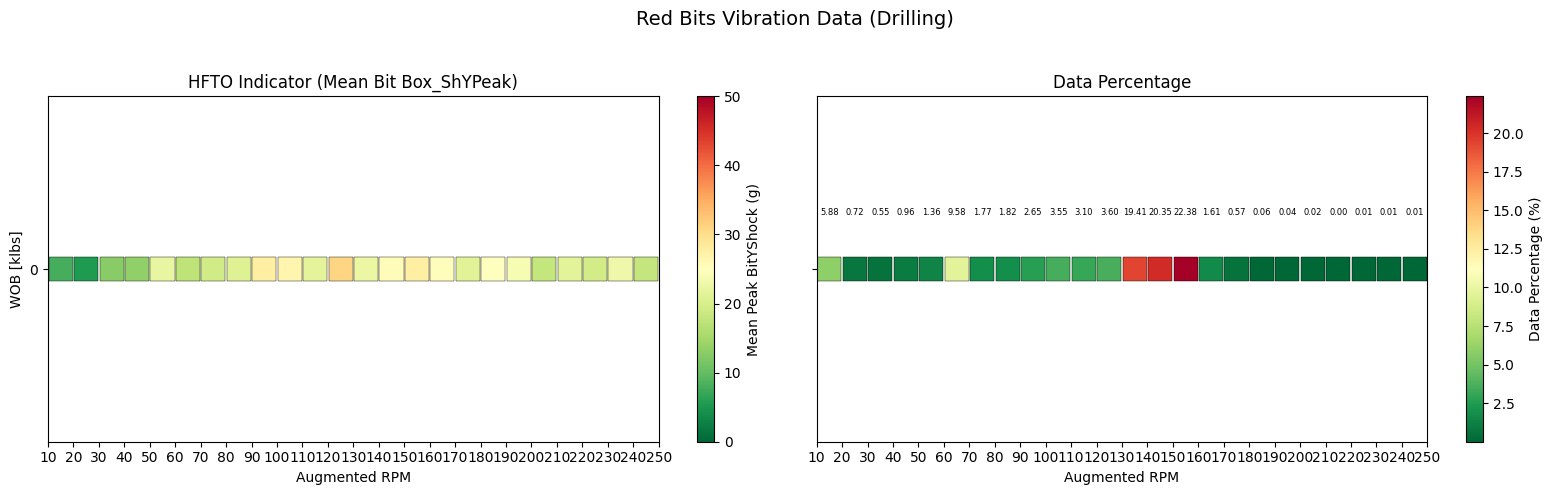

In [8]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "Green Bits Vibration Data (Drilling)": groupedNotDrilling["dataG"],
    "Blue Bits Vibration Data (Drilling)": groupedNotDrilling["dataB"],
    "Orange Bits Vibration Data (Drilling)": groupedNotDrilling["dataO"],
    "Red Bits Vibration Data (Drilling)": groupedNotDrilling["dataR"]
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = torsionalCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in states.values())
maxrpm_raw = max(df[rpm_col].max() for df in states.values())

minwob_raw = min(df[wob_col].min() for df in states.values())
#maxwob_raw = max(df[wob_col].max() for df in states.values())
maxwob_raw = 10

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShYPeak)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean Peak BitYShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])

        # keep x-axis untouched
        ax.set_xticks(rpm_edges)

        # y-axis: single tick at first bin center, labeled 0
        ax.set_yticks([wob_centers[0]])
        ax.set_yticklabels(["0"])




    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)

In [9]:
for name, df in groupedDataDrilling.items():
    df = df.loc[df["Surface_Weight on Bit(klbs)"] < 70]
    df = df.loc[df["Augmented RPM(RPM)"] >110]
    groupedDataDrilling[name] = df

for name, df in groupedNotDrilling.items():
    df = df.loc[df["Augmented RPM(RPM)"] <190]
    groupedNotDrilling[name] = df

In [10]:
CONFIG = {
    # -------------------------
    # Column definitions
    # -------------------------
    "RPM_COL": "Augmented RPM(RPM)",
    "WOB_COL": "Surface_Weight on Bit(klbs)",
    "SHOCK_COL": "Bit Box_ShYpeak(g)",

    # -------------------------
    # Grouped datasets
    # -------------------------
    # Each value must be a pandas DataFrame
    "DATASETS": {
        "Green": groupedDataDrilling["dataG"],
        "Orange": groupedDataDrilling["dataO"],
        "Blue": groupedDataDrilling["dataB"],
        "Red": groupedDataDrilling["dataR"],
    },

    # -------------------------
    # Binning
    # -------------------------
    "RPM_BIN": 10,      # RPM bin width
    "WOB_BIN": 10,      # klbf bin width

    # Region definition:
    # "TOP_Q" = bins in the top quantile of mean shock get shaded
    # Example: 0.85 => top 15% of bins
    "TOP_Q": 0.85,

    # Only consider bins with at least this many points (stability)
    "MIN_BIN_COUNT": 10,

    # Plot
    "TITLE": "HFTO operating regions (filled contours) + binned HFTO squares",
    "PAD_FRAC": 0.03,  # axis padding as fraction of data range
}


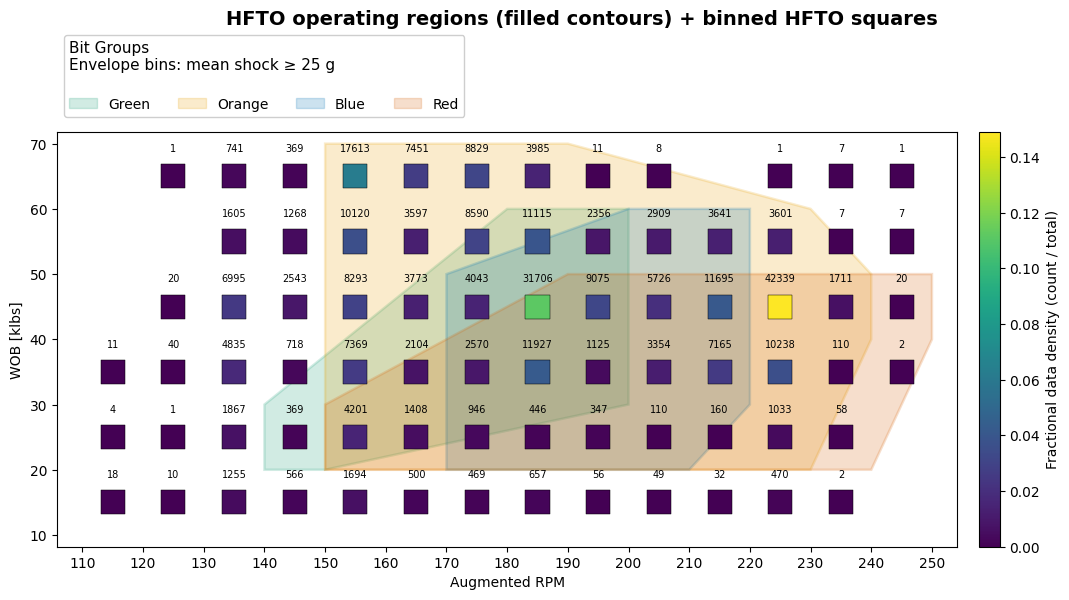

In [ ]:
"""
Binned DATA COUNT squares + Operating Envelopes (FULL SCRIPT)

Layout:
- Canvas (figure) title at top (NOT an axes title)
- Legend left-justified on top (below canvas title)
- Plot area is not squished: figure is taller + reserved top margin

Plot:
- Squares colored by FRACTIONAL DATA DENSITY: count_in_bin / total_count
- Raw DATA COUNT printed above each bin
- Plots EVERY bin with ANY data across ANY dataset (union)
- Operating envelopes are per-dataset, colored by dataset group color
  Envelope definition:
    mean(shock) >= SHOCK_THRESHOLD (default 25 g)
    AND shock_count_in_bin >= MIN_BIN_COUNT (stability)

Requirements:
  numpy, pandas, matplotlib, scipy
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch
from matplotlib.colors import Normalize
from scipy.spatial import ConvexHull


# =========================
# Helpers
# =========================
def _make_edges(vmin, vmax, step):
    lo = np.floor(vmin / step) * step
    hi = np.ceil(vmax / step) * step
    return np.arange(lo, hi + step, step)


def _mean_shock_and_count_per_bin(df, x_col, y_col, z_col, x_edges, y_edges):
    """
    Returns:
      Z: mean shock per bin
      C: count of points contributing to Z (rows with x,y,z present)
    """
    d = df[[x_col, y_col, z_col]].dropna()
    shape = (len(y_edges) - 1, len(x_edges) - 1)
    if d.empty:
        return np.full(shape, np.nan), np.zeros(shape)

    xb = pd.cut(d[x_col], bins=x_edges, include_lowest=True)
    yb = pd.cut(d[y_col], bins=y_edges, include_lowest=True)
    g = d.groupby([yb, xb], observed=True)

    meanZ = g[z_col].mean().unstack()
    cnt = g[z_col].size().unstack()

    # Reindex to full grid so shapes always match edges
    y_cats = pd.IntervalIndex.from_breaks(y_edges, closed="right")
    x_cats = pd.IntervalIndex.from_breaks(x_edges, closed="right")
    meanZ = meanZ.reindex(index=y_cats, columns=x_cats)
    cnt = cnt.reindex(index=y_cats, columns=x_cats)

    Z = meanZ.to_numpy(dtype=float)
    C = np.nan_to_num(cnt.to_numpy(dtype=float), nan=0.0)
    return Z, C


# =========================
# Main plotting function
# =========================
def plot_density_squares_plus_envelopes(
    CONFIG,
    shock_threshold=25.0,
    square_size=300,
    label_fontsize=7,
    label_y_offset_frac=0.35,
    envelope_alpha=0.20,
    envelope_linewidth=1.8,
    density_cmap="viridis",
):
    # --- config ---
    x_col = CONFIG["RPM_COL"]
    y_col = CONFIG["WOB_COL"]
    z_col = CONFIG["SHOCK_COL"]
    datasets = CONFIG["DATASETS"]

    rpm_bin = CONFIG.get("RPM_BIN", 10)
    wob_bin = CONFIG.get("WOB_BIN", 10)
    min_n_env = CONFIG.get("MIN_BIN_COUNT", 1)
    pad_frac = CONFIG.get("PAD_FRAC", 0.03)

    # Group colors for envelopes
    color_map = {
        "Green": "#1b9e77",
        "Blue": "#0072b2",
        "Orange": "#e69f00",
        "Red": "#d55e00",
    }
    color_map.update(CONFIG.get("GROUP_COLORS", {}))

    # --- global binning based on ALL RPM/WOB points across datasets ---
    all_xy = pd.concat(
        [df[[x_col, y_col]] for df in datasets.values() if df is not None],
        ignore_index=True
    )
    if all_xy.empty:
        raise ValueError("No RPM/WOB data to plot (all datasets empty).")

    x_edges = _make_edges(all_xy[x_col].min(), all_xy[x_col].max(), rpm_bin)
    y_edges = _make_edges(all_xy[y_col].min(), all_xy[y_col].max(), wob_bin)

    # centers for square markers
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2.0
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2.0
    Xc, Yc = np.meshgrid(x_centers, y_centers)

    # --- counts per bin (union across ALL datasets) ---
    H, _, _ = np.histogram2d(
        all_xy[y_col].to_numpy(),
        all_xy[x_col].to_numpy(),
        bins=[y_edges, x_edges]
    )
    total_n = H.sum()
    if total_n <= 0:
        raise ValueError("Total count is 0 after histogram2d; check inputs.")

    density = H / total_n
    base_mask = (H > 0)  # show every occupied bin

    # =========================
    # Figure layout: taller so legend+canvas title don't squish plot
    # =========================
    fig, ax = plt.subplots(figsize=(14, 6.8))

    ax.set_facecolor("white")
    ax.grid(False)

    # --- base layer: squares colored by density ---
    cmap = plt.get_cmap(density_cmap)
    vmax = float(np.nanmax(density[base_mask])) if np.any(base_mask) else 1.0
    norm = Normalize(vmin=0.0, vmax=vmax)

    sc = ax.scatter(
        Xc[base_mask].ravel(),
        Yc[base_mask].ravel(),
        c=density[base_mask].ravel(),
        cmap=cmap,
        norm=norm,
        s=square_size,
        marker="s",
        edgecolor="k",
        linewidth=0.35,
        zorder=2
    )

    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("Fractional data density (count / total)")

    # --- annotate RAW COUNT above each plotted bin ---
    y_offset = wob_bin * label_y_offset_frac
    for x0, y0, cnt in zip(
        Xc[base_mask].ravel(),
        Yc[base_mask].ravel(),
        H[base_mask].ravel()
    ):
        ax.text(
            x0,
            y0 + y_offset,
            f"{int(cnt)}",
            ha="center",
            va="bottom",
            fontsize=label_fontsize,
            color="black",
            zorder=5
        )

    # --- envelopes per dataset (mean shock >= threshold) ---
    legend_patches = []
    for name, df in datasets.items():
        if df is None or df.empty:
            continue

        Zg, Cg = _mean_shock_and_count_per_bin(df, x_col, y_col, z_col, x_edges, y_edges)

        # envelope bins: mean shock >= threshold AND enough shock samples
        occ = (Cg >= min_n_env) & np.isfinite(Zg) & (Zg >= shock_threshold)
        if not np.any(occ):
            continue

        color = color_map.get(name, "#444444")

        ys, xs = np.where(occ)
        corners = []
        for yi, xi in zip(ys, xs):
            corners.extend([
                [x_edges[xi],   y_edges[yi]],
                [x_edges[xi + 1], y_edges[yi]],
                [x_edges[xi + 1], y_edges[yi + 1]],
                [x_edges[xi],   y_edges[yi + 1]],
            ])

        if len(corners) >= 3:
            pts = np.array(corners, dtype=float)
            try:
                hull = ConvexHull(pts)
                hull_pts = pts[hull.vertices]
                ax.add_patch(Polygon(
                    hull_pts,
                    closed=True,
                    facecolor=color,
                    edgecolor=color,
                    alpha=envelope_alpha,
                    linewidth=envelope_linewidth,
                    zorder=1
                ))
            except Exception:
                pass

        legend_patches.append(
            Patch(facecolor=color, edgecolor=color, alpha=envelope_alpha, label=name)
        )

    # --- axis limits + ticks ---
    xmin, xmax = x_edges[0], x_edges[-1]
    ymin, ymax = y_edges[0], y_edges[-1]
    xr = (xmax - xmin) if xmax > xmin else 1.0
    yr = (ymax - ymin) if ymax > ymin else 1.0

    ax.set_xlim(xmin - pad_frac * xr, xmax + pad_frac * xr)
    ax.set_ylim(ymin - pad_frac * yr, ymax + pad_frac * yr)

    ax.set_xticks(np.arange(x_edges[0], x_edges[-1] + rpm_bin, rpm_bin))
    ax.set_yticks(np.arange(y_edges[0], y_edges[-1] + wob_bin, wob_bin))

    ax.set_xlabel("Augmented RPM")
    ax.set_ylabel("WOB [klbs]")

    # =========================
    # Legend ON TOP (left-justified), below canvas title
    # =========================
    if legend_patches:
        ax.legend(
            handles=legend_patches,
            title=(
                "Bit Groups\n"
                f"Envelope bins: mean shock ≥ {shock_threshold:g} g\n"
                f"and bin count ≥ {min_n_env}"
            ),
            loc="lower left",
            bbox_to_anchor=(0.0, 1.02),   # left edge of axes, above it
            ncol=max(1, len(legend_patches)),
            framealpha=0.95,
            fontsize=10,
            title_fontsize=11,
            alignment="left"
        )

    # =========================
    # Canvas (figure) title
    # =========================
    fig.suptitle(
        CONFIG.get("TITLE", "Operating envelopes + binned density squares"),
        x=0.5,          # center of canvas
        ha="center",
        fontsize=14,
        fontweight="bold",
        y=0.9
    )


    # Reserve room at top for BOTH suptitle and legend WITHOUT squishing plot
    fig.subplots_adjust(top=0.72)

    plt.show()
    return fig, ax


# =========================
# RUN
# =========================
fig, ax = plot_density_squares_plus_envelopes(CONFIG, shock_threshold=25.0)




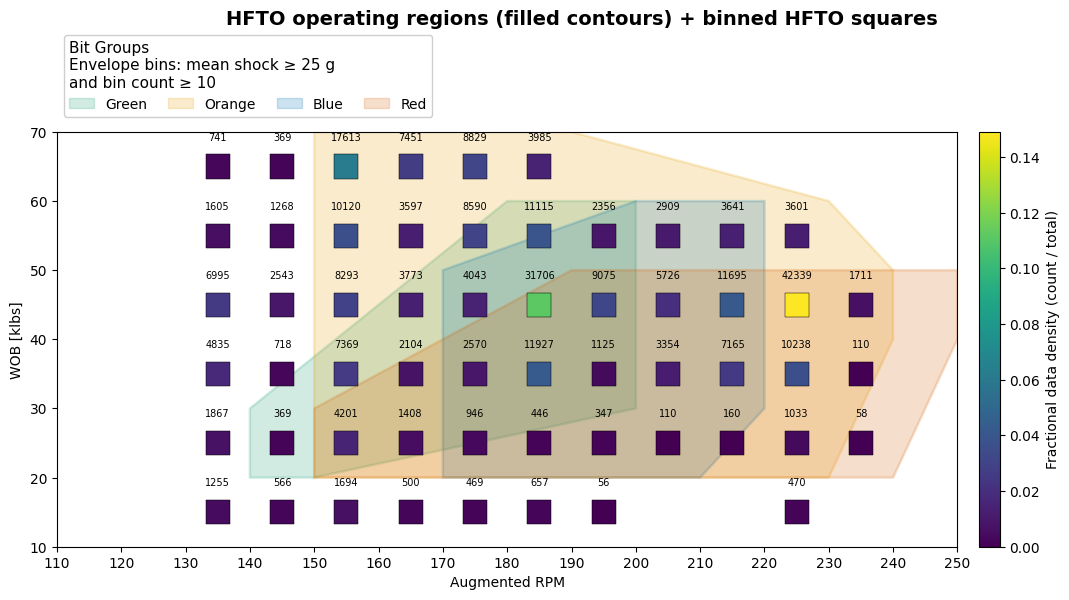

In [15]:
"""
Binned DATA COUNT squares + Operating Envelopes (FULL SCRIPT)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch
from matplotlib.colors import Normalize
from scipy.spatial import ConvexHull


# =========================
# NEW: Minimum bin count cutoff
# =========================
MIN_BIN_COUNT_DENSITY = 50   # <-- adjust this


# =========================
# Helpers
# =========================
def _make_edges(vmin, vmax, step):
    lo = np.floor(vmin / step) * step
    hi = np.ceil(vmax / step) * step
    return np.arange(lo, hi + step, step)


def _mean_shock_and_count_per_bin(df, x_col, y_col, z_col, x_edges, y_edges):
    d = df[[x_col, y_col, z_col]].dropna()
    shape = (len(y_edges) - 1, len(x_edges) - 1)
    if d.empty:
        return np.full(shape, np.nan), np.zeros(shape)

    xb = pd.cut(d[x_col], bins=x_edges, include_lowest=True)
    yb = pd.cut(d[y_col], bins=y_edges, include_lowest=True)
    g = d.groupby([yb, xb], observed=True)

    meanZ = g[z_col].mean().unstack()
    cnt = g[z_col].size().unstack()

    y_cats = pd.IntervalIndex.from_breaks(y_edges, closed="right")
    x_cats = pd.IntervalIndex.from_breaks(x_edges, closed="right")
    meanZ = meanZ.reindex(index=y_cats, columns=x_cats)
    cnt = cnt.reindex(index=y_cats, columns=x_cats)

    Z = meanZ.to_numpy(dtype=float)
    C = np.nan_to_num(cnt.to_numpy(dtype=float), nan=0.0)
    return Z, C


# =========================
# Main plotting function
# =========================
def plot_density_squares_plus_envelopes(
    CONFIG,
    shock_threshold=25.0,
    square_size=300,
    label_fontsize=7,
    label_y_offset_frac=0.35,
    envelope_alpha=0.20,
    envelope_linewidth=1.8,
    density_cmap="viridis",
):
    x_col = CONFIG["RPM_COL"]
    y_col = CONFIG["WOB_COL"]
    z_col = CONFIG["SHOCK_COL"]
    datasets = CONFIG["DATASETS"]

    rpm_bin = CONFIG.get("RPM_BIN", 10)
    wob_bin = CONFIG.get("WOB_BIN", 10)
    min_n_env = CONFIG.get("MIN_BIN_COUNT", 1)
    pad_frac = CONFIG.get("PAD_FRAC", 0.03)

    color_map = {
        "Green": "#1b9e77",
        "Blue": "#0072b2",
        "Orange": "#e69f00",
        "Red": "#d55e00",
    }
    color_map.update(CONFIG.get("GROUP_COLORS", {}))

    # -------------------------
    # Global binning
    # -------------------------
    all_xy = pd.concat(
        [df[[x_col, y_col]] for df in datasets.values() if df is not None],
        ignore_index=True
    )
    if all_xy.empty:
        raise ValueError("No RPM/WOB data to plot.")

    x_edges = _make_edges(all_xy[x_col].min(), all_xy[x_col].max(), rpm_bin)
    y_edges = _make_edges(all_xy[y_col].min(), all_xy[y_col].max(), wob_bin)

    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2
    Xc, Yc = np.meshgrid(x_centers, y_centers)

    # -------------------------
    # Histogram
    # -------------------------
    H, _, _ = np.histogram2d(
        all_xy[y_col].to_numpy(),
        all_xy[x_col].to_numpy(),
        bins=[y_edges, x_edges]
    )

    total_n = H.sum()
    if total_n <= 0:
        raise ValueError("Total count is zero.")

    density = H / total_n

    # =========================
    # NEW: Apply bin-count cutoff
    # =========================
    base_mask = H >= MIN_BIN_COUNT_DENSITY

    # -------------------------
    # Figure
    # -------------------------
    fig, ax = plt.subplots(figsize=(14, 6.8))
    ax.set_facecolor("white")
    ax.grid(False)

    cmap = plt.get_cmap(density_cmap)
    vmax = density[base_mask].max() if np.any(base_mask) else 1.0
    norm = Normalize(vmin=0.0, vmax=vmax)

    sc = ax.scatter(
        Xc[base_mask].ravel(),
        Yc[base_mask].ravel(),
        c=density[base_mask].ravel(),
        cmap=cmap,
        norm=norm,
        s=square_size,
        marker="s",
        edgecolor="k",
        linewidth=0.35,
        zorder=2
    )

    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("Fractional data density (count / total)")

    # -------------------------
    # Raw count labels (only kept bins)
    # -------------------------
    y_offset = wob_bin * label_y_offset_frac
    for x0, y0, cnt in zip(Xc[base_mask], Yc[base_mask], H[base_mask]):
        ax.text(
            x0, y0 + y_offset,
            f"{int(cnt)}",
            ha="center",
            va="bottom",
            fontsize=label_fontsize,
            zorder=5
        )

    # -------------------------
    # Envelopes (unchanged)
    # -------------------------
    legend_patches = []
    for name, df in datasets.items():
        if df is None or df.empty:
            continue

        Zg, Cg = _mean_shock_and_count_per_bin(
            df, x_col, y_col, z_col, x_edges, y_edges
        )

        occ = (Cg >= min_n_env) & np.isfinite(Zg) & (Zg >= shock_threshold)
        if not np.any(occ):
            continue

        color = color_map.get(name, "#444444")
        ys, xs = np.where(occ)

        corners = []
        for yi, xi in zip(ys, xs):
            corners.extend([
                [x_edges[xi],     y_edges[yi]],
                [x_edges[xi + 1], y_edges[yi]],
                [x_edges[xi + 1], y_edges[yi + 1]],
                [x_edges[xi],     y_edges[yi + 1]],
            ])

        pts = np.array(corners)
        hull = ConvexHull(pts)
        ax.add_patch(Polygon(
            pts[hull.vertices],
            facecolor=color,
            edgecolor=color,
            alpha=envelope_alpha,
            linewidth=envelope_linewidth,
            zorder=1
        ))

        legend_patches.append(Patch(
            facecolor=color,
            edgecolor=color,
            alpha=envelope_alpha,
            label=name
        ))

    # -------------------------
    # Axes formatting
    # -------------------------
    ax.set_xlim(x_edges[0], x_edges[-1])
    ax.set_ylim(y_edges[0], y_edges[-1])
    ax.set_xticks(np.arange(x_edges[0], x_edges[-1] + rpm_bin, rpm_bin))
    ax.set_yticks(np.arange(y_edges[0], y_edges[-1] + wob_bin, wob_bin))
    ax.set_xlabel("Augmented RPM")
    ax.set_ylabel("WOB [klbs]")

    # -------------------------
    # Legend
    # -------------------------
    if legend_patches:
        ax.legend(
            handles=legend_patches,
            title=(
                "Bit Groups\n"
                f"Envelope bins: mean shock ≥ {shock_threshold:g} g\n"
                f"and bin count ≥ {min_n_env}"
            ),
            loc="lower left",
            bbox_to_anchor=(0.0, 1.02),
            ncol=len(legend_patches),   # 🔑 THIS is the key line
            framealpha=0.95,
            fontsize=10,
            title_fontsize=11,
            alignment="left",
            columnspacing=1.5,          # optional spacing polish
            handlelength=1.8
        )


    # -------------------------
    # Canvas title
    # -------------------------
    fig.suptitle(
        CONFIG.get("TITLE", "Operating envelopes + binned density squares"),
        fontsize=14,
        fontweight="bold",
        ha="center",
        y=0.9
    )

    fig.subplots_adjust(top=0.72)
    plt.show()
    return fig, ax


# =========================
# RUN
# =========================
fig, ax = plot_density_squares_plus_envelopes(CONFIG, shock_threshold=25.0)
